# Notebook 04 — Réseau de Neurones Artificiel (ANN)

## Théorie : Artificial Neural Network

### Architecture
Un ANN est composé de **couches** (layers) :
- **Couche d'entrée** (Input Layer) : reçoit les features brutes
- **Couches cachées** (Hidden Layers) : apprennent des représentations intermédiaires
- **Couche de sortie** (Output Layer) : produit la prédiction finale

### Forward Propagation
Pour chaque neurone d'une couche :
$$z = \sum_{i} w_i x_i + b \quad \text{(combinaison linéaire)}$$
$$O = \sigma(z) \quad \text{(fonction d'activation)}$$

### Fonctions d'Activation

**Sigmoid** : $\sigma(z) = \frac{1}{1 + e^{-z}}$
- Sortie entre 0 et 1
- **Problème du Vanishing Gradient** : dérivée maximale = 0.25 → les gradients s'écrasent dans les couches profondes

**ReLU** (Rectified Linear Unit) : $f(z) = \max(0, z)$
- Dérivée = **1** pour $z > 0$ → pas d'écrasement du gradient
- Calcul très rapide
- Préféré dans les couches cachées des réseaux profonds
- Dying ReLU : neurones avec $z < 0$ toujours inactifs

### Backpropagation & Descente de Gradient
La mise à jour des poids via la règle de la chaîne :
$$w_{\text{new}} = w_{\text{old}} - \eta \cdot \frac{\partial J}{\partial w}$$

Où $\eta$ est le **learning rate** et $J$ est la fonction de coût (MSE en régression).

### Variantes de Gradient Descent
| Méthode | Taille du batch | Avantages | Inconvénients |
|---|---|---|---|
| Batch GD | Tout le dataset | Gradient exact | Lent, mémoire |
| SGD | 1 exemple | Rapide | Bruité, instable |
| **Mini-Batch GD** | 32–256 exemples | **Compromis optimal** | Hyperparamètre |

**→ Adam** combine l'**adaptivité du learning rate** (RMSProp) et la **mémoire des gradients passés** (Momentum), ce qui le rend robuste et efficace.

### Loss Function pour la Régression
$$J(\theta) = \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### Epoch
Une **epoch** = un passage complet sur l'ensemble des données d'entraînement.  
En Mini-Batch avec batch_size=32 : une epoch = $\lfloor N/32 \rfloor$ mises à jour des poids.


In [1]:
# Imports et chargement des données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import time
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)
os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)

X_train = np.load('data/X_train.npy')
X_test  = np.load('data/X_test.npy')
y_train = np.load('data/y_train.npy')
y_test  = np.load('data/y_test.npy')

n_features = X_train.shape[1]
print(f'X_train : {X_train.shape} | n_features : {n_features}')

X_train : (4700, 17) | n_features : 17


In [2]:
# Construction du modèle ANN (architecture Sequential)
# Couches Dense avec activation ReLU (évite le vanishing gradient)
ann_model = keras.Sequential([
    # Couche d'entrée → première couche cachée (128 neurones)
    layers.Dense(128, activation='relu', input_shape=(n_features,), name='dense_1'),
    # Deuxième couche cachée (64 neurones)
    layers.Dense(64, activation='relu', name='dense_2'),
    # Troisième couche cachée (32 neurones)
    layers.Dense(32, activation='relu', name='dense_3'),
    # Couche de sortie : 1 neurone, pas d'activation (régression)
    layers.Dense(1, name='output')
], name='ANN_Deforestation')

# Compilation : optimiseur Adam, loss MSE, métrique MAE
ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

ann_model.summary()

e:\Efrei\M1\S8\Machine Learning\Project\ML-Deforestation-Tonton\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Deforestation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Entraînement avec EarlyStopping pour éviter le surajustement
# patience=10 : arrêt si pas d'amélioration sur val_loss pendant 10 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

start = time.time()
history = ann_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,          # Mini-Batch Gradient Descent
    validation_split=0.2,   # 20% du train pour la validation
    callbacks=[early_stop],
    verbose=1
)
train_time = time.time() - start

print(f'\nEntraînement terminé en {train_time:.1f} secondes')
print(f'Epochs effectuées : {len(history.history["loss"])}')

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 178258083840.0000 - mae: 91525.0781 - val_loss: 100755660800.0000 - val_mae: 71366.9609
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 176559554560.0000 - mae: 90981.9453 - val_loss: 98453217280.0000 - val_mae: 70540.5156
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 164219633664.0000 - mae: 88077.4844 - val_loss: 87452876800.0000 - val_mae: 67543.0859
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 127939854336.0000 - mae: 81202.7031 - val_loss: 62772613120.0000 - val_mae: 60638.9258
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 73609003008.0000 - mae: 71482.0625 - val_loss: 33485922304.0000 - val_mae: 49911.8594
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 34742874112.0000 - mae: 63485.9023 - val_loss: 16611399680.0000 - val_mae: 39797.1484
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 22557908992.0000 - mae: 56306.4805 - val_loss: 11293

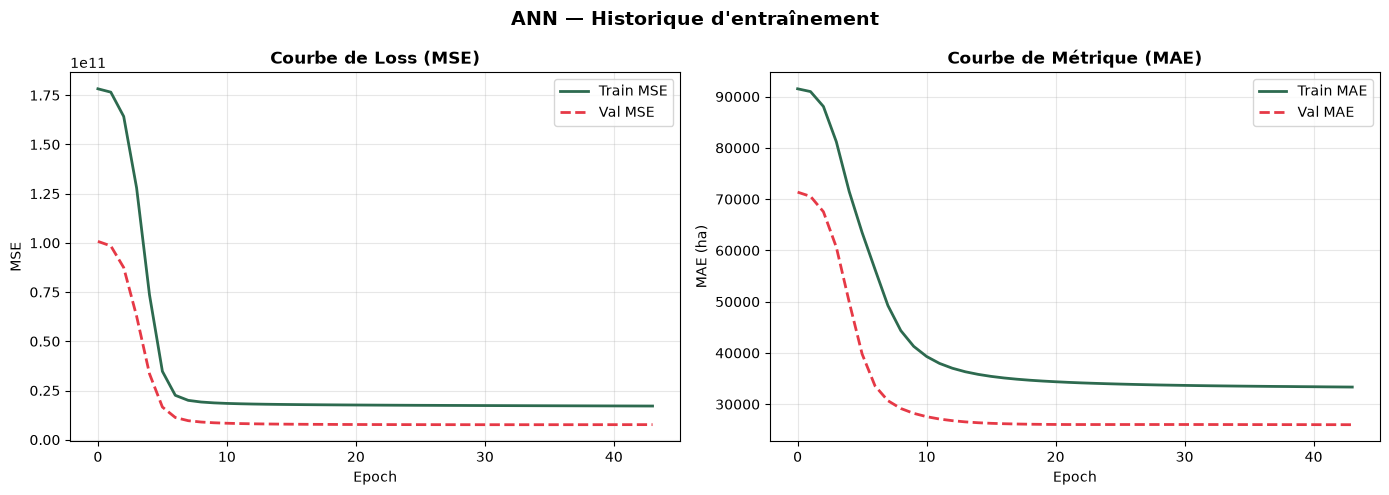

Figure sauvegardée


In [4]:
# Courbe d'apprentissage : Loss / Val_Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE
axes[0].plot(history.history['loss'], label='Train MSE', color='#2d6a4f', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val MSE', color='#e63946', linewidth=2, linestyle='--')
axes[0].set_title('Courbe de Loss (MSE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE', color='#2d6a4f', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', color='#e63946', linewidth=2, linestyle='--')
axes[1].set_title('Courbe de Métrique (MAE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (ha)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ANN — Historique d\'entraînement', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/ann_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée')

In [5]:
# Prédictions et métriques
y_pred = ann_model.predict(X_test).flatten()

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 40)
print('MÉTRIQUES — ANN')
print('=' * 40)
print(f'MAE   : {mae:,.0f} ha')
print(f'RMSE  : {rmse:,.0f} ha')
print(f'R²    : {r2:.4f}')
print(f'Temps : {train_time:.1f} s')
print('=' * 40)

results_ann = {'model': 'ANN', 'MAE': mae, 'RMSE': rmse, 'R2': r2,
               'train_time': train_time, 'y_pred': y_pred, 'y_test': y_test}
with open('models/results_ann.pkl', 'wb') as f:
    pickle.dump(results_ann, f)

# Sauvegarde du modèle Keras
ann_model.save('models/ann_model.h5')
print('Résultats et modèle sauvegardés')

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


MÉTRIQUES — ANN
MAE   : 41,830 ha
RMSE  : 253,712 ha
R²    : 0.7757
Temps : 7.7 s
Résultats et modèle sauvegardés


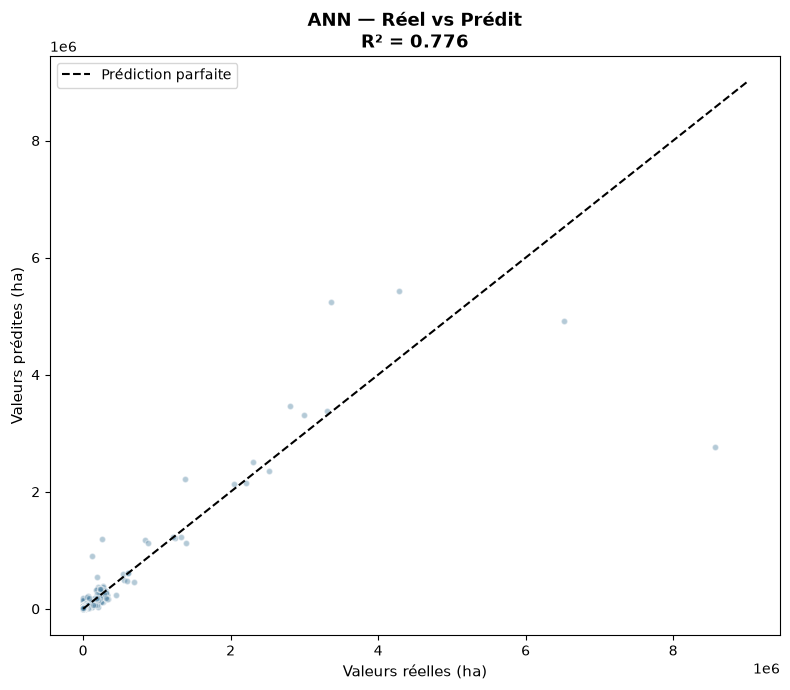

In [6]:
# Scatter plot : réel vs prédit
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test, y_pred, alpha=0.4, color='#457b9d', edgecolors='white', s=20)
lim = max(y_test.max(), y_pred.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', linewidth=1.5, label='Prédiction parfaite')
ax.set_xlabel('Valeurs réelles (ha)', fontsize=11)
ax.set_ylabel('Valeurs prédites (ha)', fontsize=11)
ax.set_title(f'ANN — Réel vs Prédit\nR² = {r2:.3f}', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/ann_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

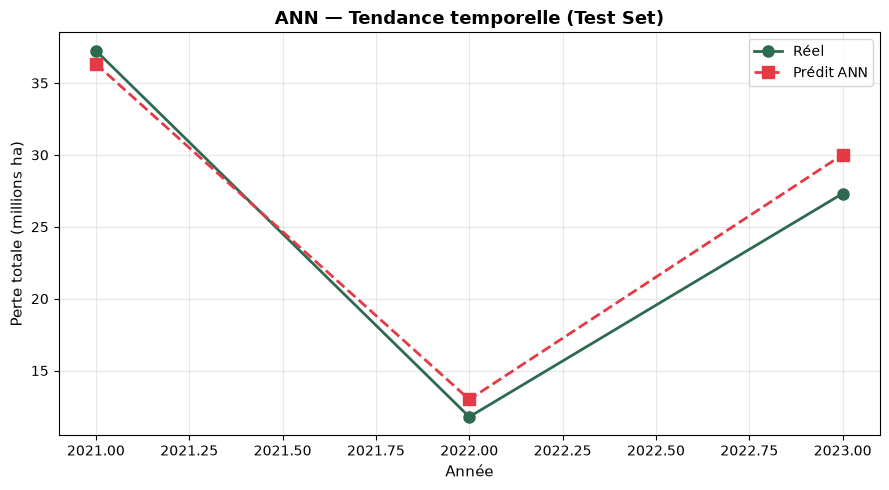

Toutes les figures sauvegardées dans figures/


In [8]:
# Courbe temporelle agrégée sur le test set
n_years_test = 3
n_per_year   = len(y_test) // n_years_test
years_test   = [2021, 2022, 2023] 
real_sum     = [y_test[i*n_per_year:(i+1)*n_per_year].sum() for i in range(n_years_test)]
pred_sum     = [y_pred[i*n_per_year:(i+1)*n_per_year].sum() for i in range(n_years_test)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(years_test, np.array(real_sum)/1e6, 'o-', color='#2d6a4f', linewidth=2, markersize=8, label='Réel')
ax.plot(years_test, np.array(pred_sum)/1e6, 's--', color='#e63946', linewidth=2, markersize=8, label='Prédit ANN')
ax.set_title('ANN — Tendance temporelle (Test Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Année', fontsize=11)
ax.set_ylabel('Perte totale (millions ha)', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/ann_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Toutes les figures sauvegardées dans figures/')